# 2. Ingeniería de Características (Feature Engineering)

En la ingeniería de características tradicional, solíamos mapear manualmente las columnas categóricas en DataFrames de pandas (por ejemplo, convirtiendo `Sex` de 'male'/'female' a 0/1, o aplicando One-Hot encoding manualmente en archivos intermedios como `data/titanic_feature.csv`).

Sin embargo, este enfoque manual tiene desventajas graves en producción:
- Propensión a errores por inconsistencias de categorías en tiempo real.
- Dificultad para mantener scripts paralelos de preprocesamiento.
- Riesgo de fuga de información (data leakage) al escalar los datos antes del split.

### Enfoque Moderno: Pipelines Automatizados

En lugar de crear archivos de datos preprocesados manualmente, utilizaremos el **ColumnTransformer** y **Pipeline** de `scikit-learn`. Este enfoque tiene grandes ventajas:
1. **Automatización Completa**: Cuando el frontend envía los datos crudos en formato JSON (ej. `Sex='female'`, `Embarked='C'`), el preprocesador empaquetado realiza la codificación One-Hot y el escalamiento estándar automáticamente en memoria.
2. **Previene Fugas**: El escalamiento estándar (`StandardScaler`) calcula la media y la desviación estándar **solo en el conjunto de entrenamiento**, y las aplica al de prueba, garantizando una correcta evaluación.
3. **Código Limpio**: Evita tener que escribir funciones de mapeo personalizadas en la API de Flask, haciendo que `app.py` sea sumamente conciso.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import QuantileTransformer

In [2]:
df = pd.read_csv('./data/titanic_clean.csv')

In [3]:
label_sex = LabelEncoder()
label_embarked = LabelEncoder()

# Fit and transform on training data
df['Sex'] = label_sex.fit_transform(df['Sex'])
df['Embarked'] = label_embarked.fit_transform(df['Embarked'])

df.sample(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
498,0,1,0,25.0,1,2,151.5500,2
890,0,3,1,32.0,0,0,7.7500,1
740,1,1,1,28.0,0,0,30.0000,2
686,0,3,1,14.0,4,1,39.6875,2
497,0,3,1,28.0,0,0,15.1000,2


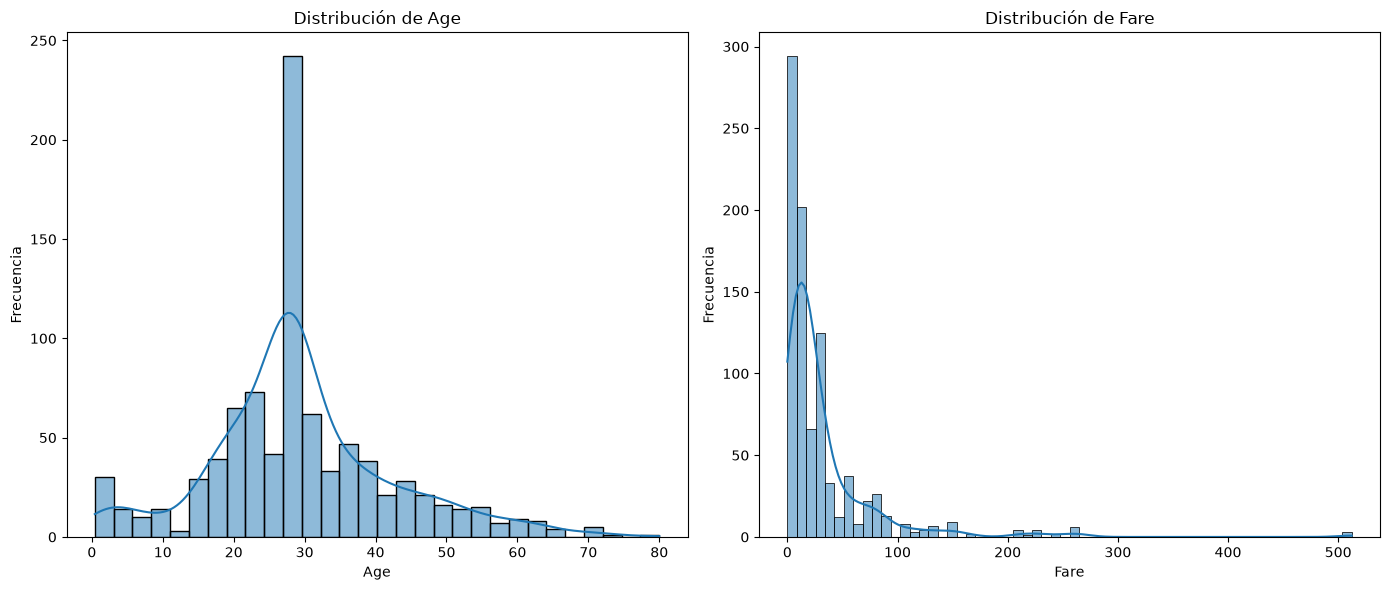

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.histplot(df['Age'].dropna(), kde=True, ax=axes[0])
axes[0].set_title('Distribución de Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frecuencia')

# Gráfica de la distribución de Fare
sns.histplot(df['Fare'].dropna(), kde=True, ax=axes[1])
axes[1].set_title('Distribución de Fare')
axes[1].set_xlabel('Fare')
axes[1].set_ylabel('Frecuencia')

# Mostrar las gráficas
plt.tight_layout()
plt.show()

In [5]:
df.sample(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
754,1,2,0,48.0,1,2,65.0000,2
430,1,1,1,28.0,0,0,26.5500,2
828,1,3,1,28.0,0,0,7.7500,1
706,1,2,0,45.0,0,0,13.5000,2
445,1,1,1,4.0,0,2,81.8583,2


In [6]:
mms_pclass= MinMaxScaler()
mms_sex = MinMaxScaler()
mms_age = MinMaxScaler()
mms_sibsp = MinMaxScaler()
mms_parch = MinMaxScaler()
mms_fare = MinMaxScaler()
mms_embarked = MinMaxScaler()

# Ejecutar transformaciones
df['Pclass'] = mms_pclass.fit_transform(df[['Pclass']])
df['Sex'] = mms_sex.fit_transform(df[['Sex']])
df['Age'] = mms_age.fit_transform(df[['Age']])
df['SibSp'] = mms_sibsp.fit_transform(df[['SibSp']])
df['Parch'] = mms_parch.fit_transform(df[['Parch']])
df['Fare'] = mms_fare.fit_transform(df[['Fare']])
df['Embarked'] = mms_embarked.fit_transform(df[['Embarked']])

In [8]:
df.sample(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
6,0,0.0,1.0,0.673285,0.000,0.000000,0.101229,1.0
21,1,0.5,1.0,0.421965,0.000,0.000000,0.025374,1.0
476,0,0.5,1.0,0.421965,0.125,0.000000,0.040989,1.0
46,0,1.0,1.0,0.346569,0.125,0.000000,0.030254,0.5
193,1,0.5,1.0,0.032420,0.125,0.166667,0.050749,1.0


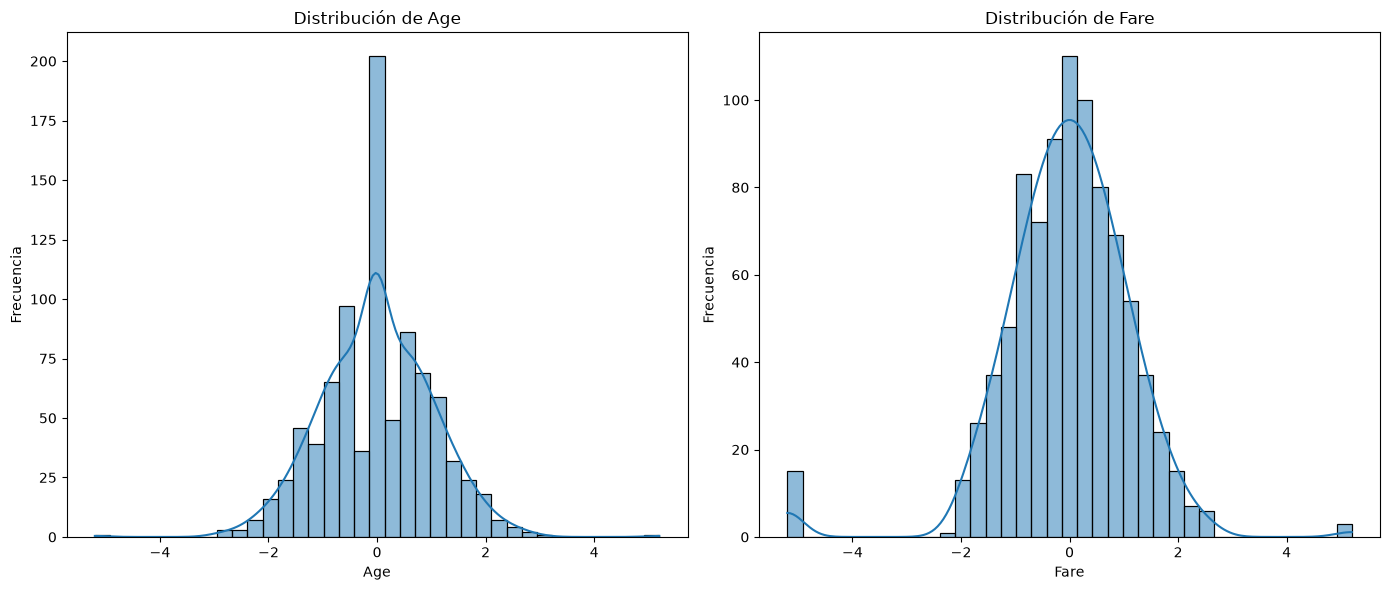

In [6]:
qun_tra_age = QuantileTransformer(output_distribution = 'normal', n_quantiles=500)
qun_tra_fare = QuantileTransformer(output_distribution = 'normal', n_quantiles=500)

df['Age'] = qun_tra_age.fit_transform(df[['Age']])
df['Fare'] = qun_tra_fare.fit_transform(df[['Fare']])


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.histplot(df['Age'].dropna(), kde=True, ax=axes[0])
axes[0].set_title('Distribución de Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frecuencia')

# Gráfica de la distribución de Fare
sns.histplot(df['Fare'].dropna(), kde=True, ax=axes[1])
axes[1].set_title('Distribución de Fare')
axes[1].set_xlabel('Fare')
axes[1].set_ylabel('Frecuencia')

# Mostrar las gráficas
plt.tight_layout()
plt.show()

In [9]:
df.to_csv('./data/titanic_procesado.csv', index=False)

In [ ]:
# Demostración del Preprocesamiento del Pipeline
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Cargar los datos limpios
df = pd.read_csv('data/titanic_clean.csv')
X = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]

# Definir columnas
numerical_cols = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
categorical_cols = ['Sex', 'Embarked']

# Crear el transformador de columnas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# Ajustar y transformar una muestra para ver los resultados mapeados
X_transformed = preprocessor.fit_transform(X)
print("Datos originales (primer registro):")
print(X.iloc[0])
print("\nDatos transformados por el preprocesador (primer registro):\n", X_transformed[0])

Datos originales (primer registro):
Pclass         3
Sex         male
Age         22.0
SibSp          1
Parch          0
Fare        7.25
Embarked       S
Name: 0, dtype: object

Datos transformados por el preprocesador (primer registro):
 [ 0.82737724 -0.56573646  0.43279337 -0.47367361 -0.50244517  0.
  1.          0.          0.          1.        ]
